In [2]:
from google.colab import files
uploaded = files.upload()

Saving train_dataset (1).csv to train_dataset (1) (1).csv
Saving test_dataset (1).csv to test_dataset (1).csv


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load CSVs
train_df = pd.read_csv("train_dataset.csv")
test_df = pd.read_csv("test_dataset.csv")

# Create synthetic SoC labels (replace with real SoC later!)
def generate_soc(df):
    soc = (df["Voltage"] - 3.0) / (4.2 - 3.0) * 100
    soc -= df["Current"] * 2
    soc -= (df["Temperature"] - 25) * 0.2
    return np.clip(soc, 0, 100)

train_df["SoC"] = generate_soc(train_df)
test_df["SoC"] = generate_soc(test_df)



In [6]:
# Prepare data
X_train = train_df[["Voltage", "Current", "Power", "Temperature"]].values
y_train = train_df["SoC"].values
X_test = test_df[["Voltage", "Current", "Power", "Temperature"]].values
y_test = test_df["SoC"].values

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))




In [7]:
# Build CNN
model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(4,1),padding = "same"),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=2, activation='relu',padding = "same"),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=30, batch_size=32, verbose=1)



Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3160.3350 - mae: 47.9100 - val_loss: 2663.4150 - val_mae: 43.0775
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2940.9294 - mae: 45.7985 - val_loss: 1975.6179 - val_mae: 35.6939
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1910.8737 - mae: 35.8199 - val_loss: 846.7589 - val_mae: 24.4860
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 977.5428 - mae: 26.3155 - val_loss: 843.9471 - val_mae: 24.6833
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 901.7816 - mae: 25.6834 - val_loss: 829.8354 - val_mae: 24.4953
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 871.1627 - mae: 25.0959 - val_loss: 817.2481 - val_mae: 24.3235
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 915.4421 - mae: 25.5868 - val_loss: 811.0283 - val_mae: 24.2786
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 845.7243 - mae: 24.5729 - val_loss: 807.7507 - val_mae: 24.2684
Epoch 9/30
25/25 ━━━━━━━━━━━━

Test MAE: 11.93
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predicted SoC: 53.56% | Actual SoC: 65.73%
Predicted SoC: 53.79% | Actual SoC: 75.86%
Predicted SoC: 39.30% | Actual SoC: 19.69%
Predicted SoC: 68.79% | Actual SoC: 64.56%
Predicted SoC: 57.03% | Actual SoC: 56.63%
Predicted SoC: 84.84% | Actual SoC: 85.70%
Predicted SoC: 83.12% | Actual SoC: 88.84%
Predicted SoC: 18.06% | Actual SoC: 0.00%
Predicted SoC: 48.94% | Actual SoC: 66.06%
Predicted SoC: 12.11% | Actual SoC: 7.58%
Predicted SoC: 68.08% | Actual SoC: 58.78%
Predicted SoC: 25.00% | Actual SoC: 27.09%
Predicted SoC: 42.11% | Actual SoC: 27.42%
Predicted SoC: 34.65% | Actual SoC: 35.57%
Predicted SoC: 47.00% | Actual SoC: 61.01%
Predicted SoC: 36.40% | Actual SoC: 35.27%
Predicted SoC: 55.34% | Actual SoC: 70.97%
Predicted SoC: 52.09% | Actual SoC: 36.68%
Predicted SoC: 18.22% | Actual SoC: 6.66%
Predicted SoC: 76.37% | Actual SoC: 77.25%
Predicted SoC: 26.66% | Actual SoC: 26.95%
Predicted SoC: 45.06% | Actual SoC: 44.18%
P

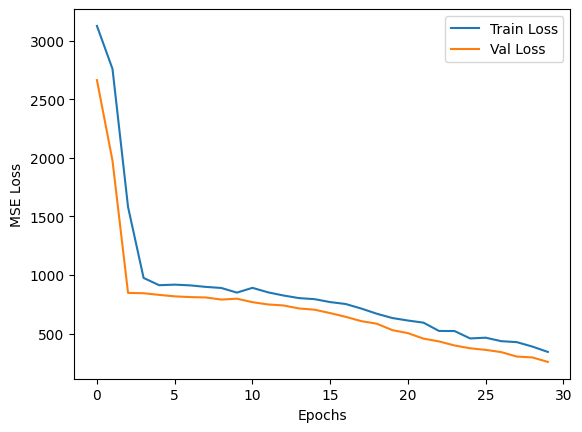

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


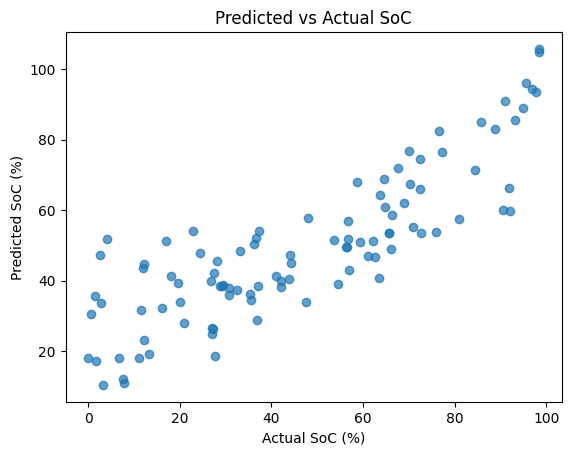

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {mae:.2f}")

# Predictions
preds = model.predict(X_test)
for i, p in enumerate(preds):
    print(f"Predicted SoC: {p[0]:.2f}% | Actual SoC: {y_test[i]:.2f}%")
import matplotlib.pyplot as plt

# Training curves
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# Predicted vs Actual
plt.scatter(y_test[:100], model.predict(X_test[:100]), alpha=0.7)
plt.xlabel("Actual SoC (%)")
plt.ylabel("Predicted SoC (%)")
plt.title("Predicted vs Actual SoC")
plt.show()

In [20]:
import numpy as np

y_testf = y_test.flatten()
y_preds = preds.flatten()

mean_error = np.mean(np.abs( y_testf - y_preds ))
accuracy = 100 - mean_error
print(f"the accuracy is {accuracy}")

the accuracy is 88.07062082896364
